In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter, MaxNLocator
import seaborn as sns

# Color palette - Okabe–Ito colorblind-friendly
PALETTE = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "green":  "#009E73",
    "sky":    "#56B4E9",
    "red":    "#D55E00",
    "pink":   "#CC79A7",
    "yellow": "#F0E442",
    "black":  "#000000",
}

def plot_comparison_single(
    data_series,
    title,
    xlabel="Training Episodes",
    ylabel="Win Rate (%)",
    figsize=(11, 6),
    as_percentage=True,
    ylim=(0, 105)
):
    """
    Plot multiple data series on a single figure.
    
    Args:
        data_series: List of tuples (x_data, y_data, label, color, marker)
                     where marker is a string like 'o', 's', '^', etc.
        title: Title of the plot
        xlabel: X-axis label
        ylabel: Y-axis label
        figsize: Figure size (width, height)
        as_percentage: Format y-axis as percentage
        ylim: Y-axis limits
    
    Returns:
        fig, ax
    """
    plt.rcParams['font.size'] = 12
    fig, ax = plt.subplots(figsize=figsize)
    
    markers = ['o', 's', '^', 'D', 'v', '*']
    
    for idx, (x_data, y_data, label, color, marker) in enumerate(data_series):
        y_data *= 100
        ax.plot(x_data, y_data, lw=3.5, label=label, color=color,
                marker=marker, markersize=5, markerfacecolor=color,
                markeredgewidth=1.5, markeredgecolor='white')
        ax.fill_between(x_data, y_data, alpha=0.1, color=color)
    
    # Styling
    ax.set_xlabel(xlabel, fontweight="bold", fontsize=13)
    ax.set_ylabel(ylabel, fontweight="bold", fontsize=13)
    ax.set_title(title, fontweight="bold", fontsize=14)
    ax.grid(True, alpha=0.25, linewidth=1)
    ax.legend(frameon=False, fontsize=12, loc='best')
    
    # Remove top and right spines
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    
    # Format y-axis as percentage if needed
    if as_percentage:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100.0))
    
    ax.set_ylim(ylim)
    
    plt.tight_layout()
    return fig, ax

['episode_num', 'num_steps', 'MiniTank_Win_Rate', 'Crazyflie_Win_Rate']
['episode_num', 'num_steps', 'MiniTank_Win_Rate', 'Crazyflie_Win_Rate']


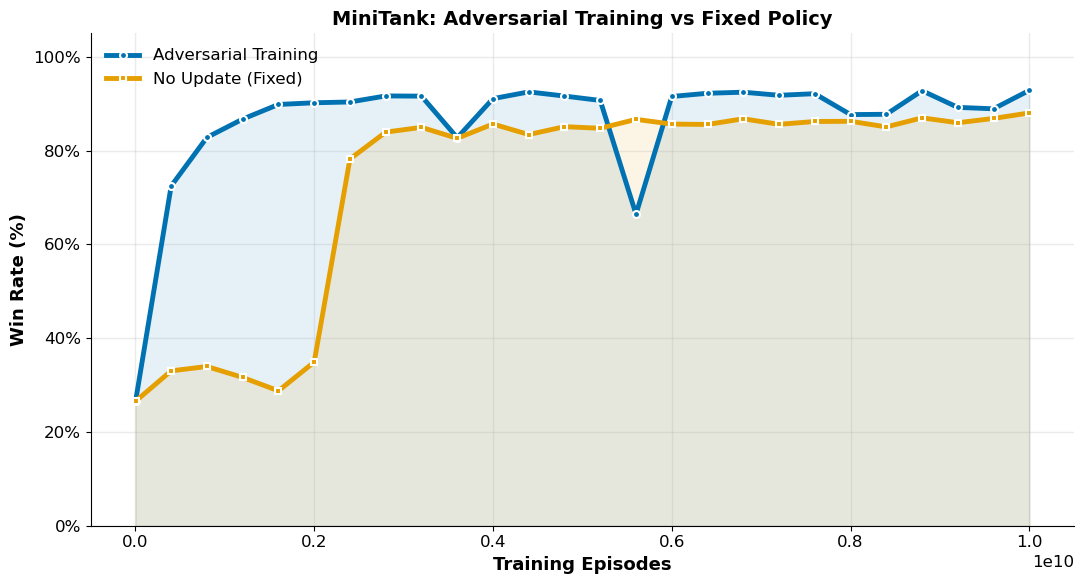

In [3]:
minitank_vs_drone_res = np.load("/home/isaacp/repos/direct/IsaacLab-HARL/scripts/reinforcement_learning/harl/slurm_jobs/results/isaaclab/Minitank-Adversarial-Direct-v0/happo_adv/test/adversarial_training/results_analysis/all_results.npz")
print(list(minitank_vs_drone_res.keys()))
num_steps = minitank_vs_drone_res["num_steps"]

minitank_vs_drone_res_no_update = np.load("/home/isaacp/repos/direct/IsaacLab-HARL/scripts/reinforcement_learning/harl/slurm_jobs/results/isaaclab/Minitank-Adversarial-Direct-v0/happo_adv/test/no_update_for_cf/results_analysis/all_results.npz")
print(list(minitank_vs_drone_res_no_update.keys()))
num_steps_no_update = minitank_vs_drone_res_no_update["num_steps"]

minitank_win_rate = minitank_vs_drone_res["MiniTank_Win_Rate"]
minitank_win_rate_no_updates = minitank_vs_drone_res_no_update["MiniTank_Win_Rate"]

# Plot using the generalized function
data_series = [
    (num_steps, minitank_win_rate, "Adversarial Training", PALETTE["blue"], 'o'),
    (num_steps_no_update, minitank_win_rate_no_updates, "No Update (Fixed)", PALETTE["orange"], 's'),
]

fig, ax = plot_comparison_single(
    data_series,
    title="MiniTank: Adversarial Training vs Fixed Policy",
    ylabel="Win Rate (%)"
)
plt.show()

['episode_num', 'num_steps', 'team0_win_percentage', 'team1_win_percentage', 'Episode_Reward/team_0_push_out_reward', 'Episode_Reward/team_1_push_out_reward']
['episode_num', 'num_steps', 'team0_win_percentage', 'team1_win_percentage', 'Episode_Reward/team_0_push_out_reward', 'Episode_Reward/team_1_push_out_reward']


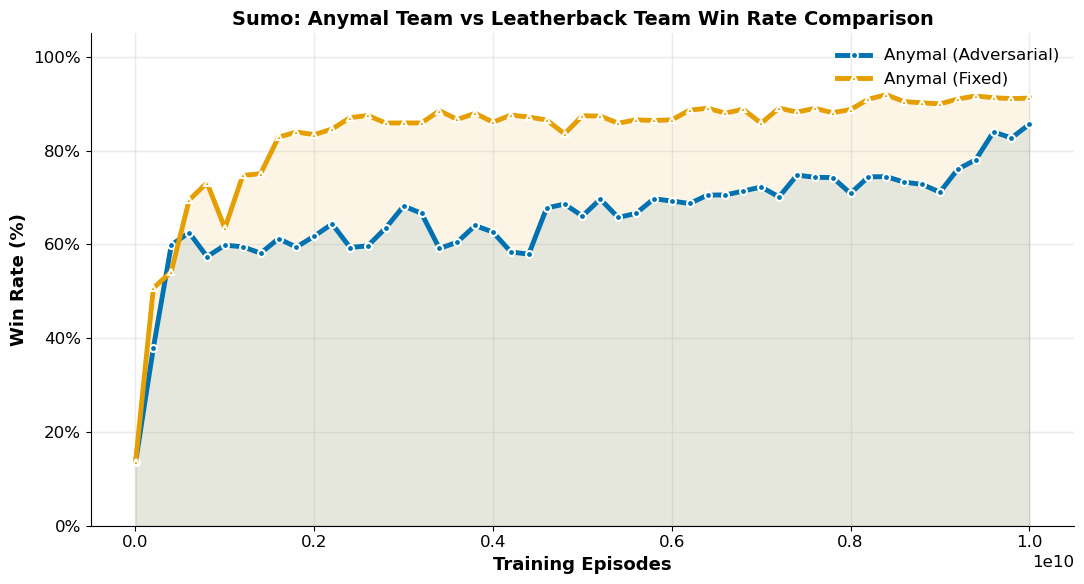

In [4]:
an_vs_lb_sumo = np.load("/home/isaacp/repos/direct/IsaacLab-HARL/scripts/reinforcement_learning/harl/slurm_jobs/results/isaaclab/Sumo-Stage2-Hetero-By-Team-v0/happo_adv/sumo_lb_vs_anym_happo_adv/seed-00001-2026-02-19-18-25-38/results_analysis/all_results.npz")
print(list(an_vs_lb_sumo.keys()))
num_steps = an_vs_lb_sumo["num_steps"]

an_vs_lb_sumo_no_lb_update = np.load("/home/isaacp/repos/direct/IsaacLab-HARL/scripts/reinforcement_learning/harl/slurm_jobs/results/isaaclab/Sumo-Stage2-Hetero-By-Team-v0/happo_adv/no_update_sumo_lb_vs_anym_happo_adv/seed-00001-2026-02-19-19-38-10/results_analysis/all_results.npz")
print(list(an_vs_lb_sumo_no_lb_update.keys()))
num_steps_no_update = an_vs_lb_sumo_no_lb_update["num_steps"]

anymal_win_rate = an_vs_lb_sumo["team0_win_percentage"]
lb_win_rate = an_vs_lb_sumo["team1_win_percentage"]
anymal_win_rate_no_updates = an_vs_lb_sumo_no_lb_update["team0_win_percentage"]
lb_win_rate_no_updates = an_vs_lb_sumo_no_lb_update["team1_win_percentage"]

# Plot using the generalized function
data_series = [
    (num_steps, anymal_win_rate, "Anymal (Adversarial)", PALETTE["blue"], 'o'),
    (num_steps_no_update, anymal_win_rate_no_updates, "Anymal (Fixed)", PALETTE["orange"], '^'),
]

fig, ax = plot_comparison_single(
    data_series,
    title="Sumo: Anymal Team vs Leatherback Team Win Rate Comparison",
    ylabel="Win Rate (%)"
)
plt.show()

['episode_num', 'num_steps', 'Episode_Reward/team_0_score_reward', 'Episode_Reward/team_0_ball_to_goal_reward', 'Episode_Reward/team_0_timestep_reward', 'Episode_Reward/team_1_score_reward', 'Episode_Reward/team_1_ball_to_goal_reward', 'Episode_Reward/team_1_timestep_reward', 'Team0_Percent_Scored', 'Team1_Percent_Scored']
['episode_num', 'num_steps', 'Episode_Reward/team_0_score_reward', 'Episode_Reward/team_0_ball_to_goal_reward', 'Episode_Reward/team_0_timestep_reward', 'Episode_Reward/team_1_score_reward', 'Episode_Reward/team_1_ball_to_goal_reward', 'Episode_Reward/team_1_timestep_reward', 'Team0_Percent_Scored', 'Team1_Percent_Scored']


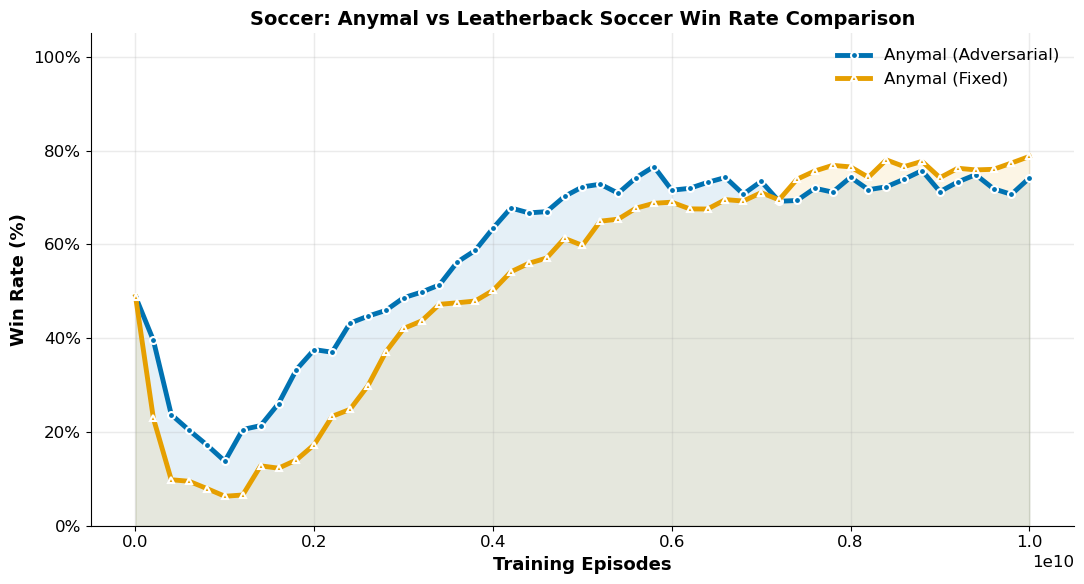

In [7]:
an_vs_lb_soccer = np.load("/home/isaacp/repos/direct/IsaacLab-HARL/scripts/reinforcement_learning/harl/slurm_jobs/results/isaaclab/AnymalC-VS-Leatherback-Soccer-v0/happo_adv/soccer_lb_vs_anym_happo_adv/seed-00001-2026-02-23-20-09-53/results_analysis/soccer_lb_vs_anym_happo_adv/2026-02-25_12-38-12/all_results.npz")
print(list(an_vs_lb_soccer.keys()))
num_steps = an_vs_lb_soccer["num_steps"]

an_vs_lb_soccer_no_lb_update = np.load("/home/isaacp/repos/direct/IsaacLab-HARL/scripts/reinforcement_learning/harl/slurm_jobs/results/isaaclab/AnymalC-VS-Leatherback-Soccer-v0/happo_adv/soccer_lb_vs_anym_happo_adv_no_updates/seed-00001-2026-02-23-20-34-38/results_analysis/soccer_lb_vs_anym_happo_adv_no_updates/2026-02-25_12-38-18/all_results.npz")
print(list(an_vs_lb_soccer_no_lb_update.keys()))
num_steps_no_update = an_vs_lb_soccer_no_lb_update["num_steps"]

anymal_win_rate = an_vs_lb_soccer["Team0_Percent_Scored"]
lb_win_rate = an_vs_lb_soccer["Team1_Percent_Scored"]
anymal_win_rate_no_updates = an_vs_lb_soccer_no_lb_update["Team0_Percent_Scored"]
lb_win_rate_no_updates = an_vs_lb_soccer_no_lb_update["Team1_Percent_Scored"]

# Plot using the generalized function
data_series = [
    (num_steps, anymal_win_rate, "Anymal (Adversarial)", PALETTE["blue"], 'o'),
    (num_steps_no_update, anymal_win_rate_no_updates, "Anymal (Fixed)", PALETTE["orange"], '^'),
]

fig, ax = plot_comparison_single(
    data_series,
    title="Soccer: Anymal vs Leatherback Soccer Win Rate Comparison",
    ylabel="Win Rate (%)"
)
plt.show()